# 09. Comparación de calibradores y fundamento de los escenarios de costo

El diagnóstico 08 mostró que las probabilidades calibradas no representan igualmente bien todos los grupos de monto y riesgo. Antes de cerrar el método contrastamos las dos alternativas que contempla la propuesta: Platt e isotónica. Mantenemos el mismo XGBoost y las mismas operaciones; solo añadimos un calibrador candidato.

Este experimento surge de resultados ya observados en desarrollo. La validación posterior está reutilizada: no la presentaremos como confirmación independiente. No puntuamos test, no seleccionamos Ca por ahorro y no sustituimos automáticamente el calibrador del 06.

## 1. Qué respalda la literatura y qué sigue siendo un supuesto

La propuesta entregada, sección 9, página 3, contempla «regresión isotónica o de Platt». Compararlas no introduce otra familia de clasificadores ni obliga a cambiar el XGBoost.

Para Ca distinguimos dos conjuntos antes de calcular resultados:

- **Inspirados en literatura:** 1, 2,5, 5 y 10. [Bahnsen et al. (2013)](https://albahnsen.github.io/files/Cost%20Sensitive%20Credit%20Card%20Fraud%20Detection%20using%20Bayes%20Minimum%20Risk%20-%20Publish.pdf) usan 2,50 euros y sensibilidad con 1, 2,50 y 5 euros; [Bahnsen et al. (2014)](https://albahnsen.github.io/files/%20Improving%20Credit%20Card%20Fraud%20Detection%20by%20using%20Calibrated%20Probabilities%20-%20Publish.pdf) usan 10 euros con apoyo del equipo de riesgo de la empresa estudiada.
- **Sensibilidad ampliada:** 20, 50 y 100, conservados para describir otros regímenes de intervención, no como costos operativos respaldados por esos artículos.

Los estudios trabajaron con otra empresa, otras fechas y montos en euros. Sus valores no son mediciones de IEEE-CIS. Aquí usamos las magnitudes numéricas como supuestos en unidades del dataset; no afirmamos equivalencia económica ni hacemos conversión de moneda ni reportamos dólares. Añadir 2,5 no cambia retrospectivamente los escenarios ni los resultados del 07/08.

El costo administrativo es un parámetro exógeno del problema. Escoger Ca porque produce el mayor ahorro mezclaría el supuesto económico con el resultado que queremos medir. El acuerdo sobre los escenarios finales sigue pendiente.

## 2. Diseño y criterios de lectura

Conservamos el XGBoost, su preprocesamiento, el estado histórico congelado y el Platt del 06. Reconstruimos las puntuaciones tempranas con ese predictor; isotónica se ajusta únicamente sobre las 42.046 operaciones tempranas. Contrastamos en las 42.047 posteriores y verificamos que raw y Platt reproduzcan los scores guardados.

Platt aplica una transformación sigmoidal al logit recortado de la probabilidad original, como quedó implementado en el 06. Isotónica aprende una transformación no decreciente sobre la probabilidad original, sin asumir forma sigmoidal; puede crear mesetas, empates y probabilidades extremas. Usamos `increasing=True`, límites [0,1] y `out_of_bounds='clip'`: fuera del rango temprano conserva el valor del extremo aprendido. No añadimos pesos, remuestreo ni suavizado después de observar el diagnóstico. [Documentación oficial](https://scikit-learn.org/stable/modules/calibration.html).

Fijamos como lectura principal log-loss global posterior y complementamos con Brier, confiabilidad por grupos, montos y subperiodos. Son medidas de calidad probabilística, no certificados aislados de calibración. El costo BMR será diagnóstico, no un selector diferente para cada Ca. La versión raw sirve de referencia y no se aprueba automáticamente como alternativa final sin calibración.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from fraud_cost.paths import PROJECT_ROOT
from fraud_cost.calibration import (
    DIAGNOSTIC_CA, load_calibration_inputs, compare_calibrators,
    calibration_figures, save_calibration_experiment,
)

CA_GRID = DIAGNOSTIC_CA
predictor, early, policy, saved_scores, refit_config = load_calibration_inputs(PROJECT_ROOT)
print(f'Calibración temprana: {len(early):,}; diagnóstico posterior: {len(policy):,}.')
print('Sin reajuste del XGBoost, preprocesamiento, Platt ni estado histórico.')

Fuentes verificadas. Cargando únicamente train y validación para reconstruir las ventanas.


Calibración temprana: 42,046; diagnóstico posterior: 42,047.
Sin reajuste del XGBoost, preprocesamiento, Platt ni estado histórico.


In [2]:
isotonic, candidate_scores, metrics, groups, comparison, changes, diagnostics = compare_calibrators(
    predictor, early, policy, saved_scores, ca_grid=CA_GRID,
)
display(metrics[['method', 'rows', 'frauds', 'average_precision', 'brier_score',
                 'log_loss', 'mean_probability', 'recall_at_fixed_0_5']].round(8))
display(metrics[['method', 'unique_probabilities', 'rows_in_tied_probabilities',
                 'probability_zero_count', 'probability_one_count',
                 'frauds_with_probability_zero', 'legitimate_with_probability_one']])
print(f"Isotónica: {diagnostics['isotonic_knots']} nodos; "
      f"{diagnostics['policy_below_calibration_raw_min']} scores posteriores bajo el mínimo temprano y "
      f"{diagnostics['policy_above_calibration_raw_max']} sobre el máximo.")

Reconstruidas puntuaciones posteriores. Inferencia temprana para 42,046 operaciones.


Isotónica ajustada solo en validación temprana; predictor y Platt intactos.


,method,rows,frauds,average_precision,brier_score,log_loss,mean_probability,recall_at_fixed_0_5
0,raw,42047,1517,0.464794,0.024942,0.100791,0.033019,0.284773
1,platt,42047,1517,0.464794,0.025003,0.101156,0.031323,0.278840
2,isotonic,42047,1517,0.447268,0.024916,0.100887,0.031489,0.295979


,method,unique_probabilities,rows_in_tied_probabilities,probability_zero_count,probability_one_count,frauds_with_probability_zero,legitimate_with_probability_one
0,raw,41920,254,0,0,0,0
1,platt,41920,254,0,0,0,0
2,isotonic,82,42010,819,1,1,0


Isotónica: 92 nodos; 1 scores posteriores bajo el mínimo temprano y 0 sobre el máximo.


## 3. Qué ocurre en grupos comunes y a lo largo del tiempo

Reutilizamos las seis bandas de monto, las seis de riesgo Platt y los cuatro intervalos temporales del 08. Todas las versiones se evalúan en las mismas operaciones de cada grupo. No agrupamos cada calibrador por sus propias predicciones ni aprendemos cortes de las etiquetas.

La tasa observada menos p media señala subestimación si es positiva. Σ(yᵢ−pᵢ)Aᵢ señala el residuo ponderado por monto sobre todas las operaciones, no la pérdida de una política. Incluimos tamaños y fraudes: una discrepancia en un grupo pequeño no es una estimación robusta ni identifica su causa.

In [3]:
group_columns = ['group_label', 'method', 'rows', 'frauds', 'observed_rate',
                 'mean_probability', 'brier_score', 'log_loss',
                 'fraud_amount_observed', 'fraud_amount_expected']
display(groups.loc[groups.grouping.eq('amount'), group_columns].round(6))
display(groups.loc[groups.grouping.eq('period'), group_columns].round(6))

,group_label,method,rows,frauds,observed_rate,mean_probability,brier_score,log_loss,fraud_amount_observed,fraud_amount_expected
3,"[0, 50)",raw,13918,513,0.036859,0.036075,0.022998,0.093205,14055.747,13692.472066
4,"[0, 50)",platt,13918,513,0.036859,0.034624,0.023056,0.093555,14055.747,13065.571320
5,"[0, 50)",isotonic,13918,513,0.036859,0.034289,0.022912,0.094047,14055.747,12909.057069
6,"[50, 100)",raw,11495,355,0.030883,0.025059,0.021555,0.091120,24520.048,19843.115316
7,"[50, 100)",platt,11495,355,0.030883,0.023560,0.021616,0.091618,24520.048,18664.248788
8,"[50, 100)",isotonic,11495,355,0.030883,0.023527,0.021523,0.091353,24520.048,18685.803638
9,"[100, 250)",raw,12075,395,0.032712,0.031200,0.025273,0.102814,61271.060,57391.270725
10,"[100, 250)",platt,12075,395,0.032712,0.029380,0.025314,0.103088,61271.060,54098.807322
11,"[100, 250)",isotonic,12075,395,0.032712,0.029779,0.025273,0.102087,61271.060,54974.601321
12,"[250, 500)",raw,2742,125,0.045587,0.042501,0.032476,0.125536,43417.257,41155.126525


,group_label,method,rows,frauds,observed_rate,mean_probability,brier_score,log_loss,fraud_amount_observed,fraud_amount_expected
39,1,raw,10888,447,0.041054,0.036195,0.027791,0.109931,75779.332,62665.138788
40,1,platt,10888,447,0.041054,0.034462,0.027891,0.110474,75779.332,59297.568812
41,1,isotonic,10888,447,0.041054,0.034636,0.027678,0.108473,75779.332,60823.776438
42,2,raw,10419,335,0.032153,0.029412,0.022000,0.091470,61583.477,53817.115330
43,2,platt,10419,335,0.032153,0.027733,0.022040,0.091685,61583.477,51034.625429
44,2,isotonic,10419,335,0.032153,0.027962,0.022061,0.091507,61583.477,52312.394565
45,3,raw,10783,402,0.037281,0.034216,0.026454,0.105554,70206.314,61644.377890
46,3,platt,10783,402,0.037281,0.032471,0.026535,0.105959,70206.314,58281.756827
47,3,isotonic,10783,402,0.037281,0.032805,0.026449,0.107334,70206.314,59504.411728
48,4,raw,9957,333,0.033444,0.032026,0.023269,0.095390,46967.689,48564.057699


## 4. Consecuencias económicas sin cambiar la comparación principal

Para cada Ca comparamos BMR con probabilidades raw, Platt e isotónicas. La política fija Platt 0,5 del 07 permanece como referencia común: no la redefinimos para cada calibrador, porque cambiaría dos elementos simultáneamente.

Esto es un diagnóstico de probabilidades dentro de BMR, **no una nueva comparación final de cuatro políticas**. Los árboles del 07 no se reajustan ni participan en esta tabla. El corte clasificatorio sigue siendo 0,5, aunque las métricas predictivas de cada versión pueden cambiar al transformar probabilidades.

Descomponemos el delta isotónica−Platt en administración y fraude aprobado. Un valor negativo indica menor costo realizado isotónico para ese Ca. Que un calibrador mejore Brier o log-loss no obliga a que mejore ese costo en todos los escenarios.

In [4]:
display(comparison.pivot(index='administrative_cost_ca', columns='strategy',
                         values='cost_total_proxy').round(3))
display(changes[['administrative_cost_ca', 'actions_changed', 'additional_interventions',
                 'fewer_interventions', 'isotonic_minus_platt_cost',
                 'administrative_cost_delta', 'missed_fraud_amount_delta']].round(3))

strategy,bmr_isotonic,bmr_platt,bmr_raw,fixed_0_5
administrative_cost_ca,,,,
1.0,24790.922,24960.249,25225.644,200631.515
2.5,44523.252,45491.136,45376.757,201476.015
5.0,64483.044,65114.851,65684.903,202883.515
10.0,88243.252,88400.085,88354.988,205698.515
20.0,118702.744,118762.070,118750.707,211328.515
50.0,164611.371,165184.051,165571.685,228218.515
100.0,198436.228,198291.022,197962.022,256368.515


,administrative_cost_ca,actions_changed,additional_interventions,fewer_interventions,isotonic_minus_platt_cost,administrative_cost_delta,missed_fraud_amount_delta
0,1.0,1749,175,1574,-169.327,-1399.0,1229.673
1,2.5,865,369,496,-967.884,-317.5,-650.384
2,5.0,667,385,282,-631.807,515.0,-1146.807
3,10.0,444,298,146,-156.833,1520.0,-1676.833
4,20.0,239,158,81,-59.326,1540.0,-1599.326
5,50.0,104,89,15,-572.680,3700.0,-4272.680
6,100.0,50,35,15,145.206,2000.0,-1854.794


## 5. Evidencia y reproducción

Guardamos cuatro tablas agregadas, dos figuras y la configuración. El calibrador isotónico candidato queda local e ignorado por Git, vinculado por hash al predictor original. Se aplica a la probabilidad raw, no al logit; no sustituye el calibrador dentro de `selected_xgboost_platt.joblib`. No exportamos otro archivo por transacción.

La lógica reutilizable está en `src/fraud_cost/calibration.py`. La selección final requiere una decisión explícita y un protocolo congelado; este notebook no habilita test.

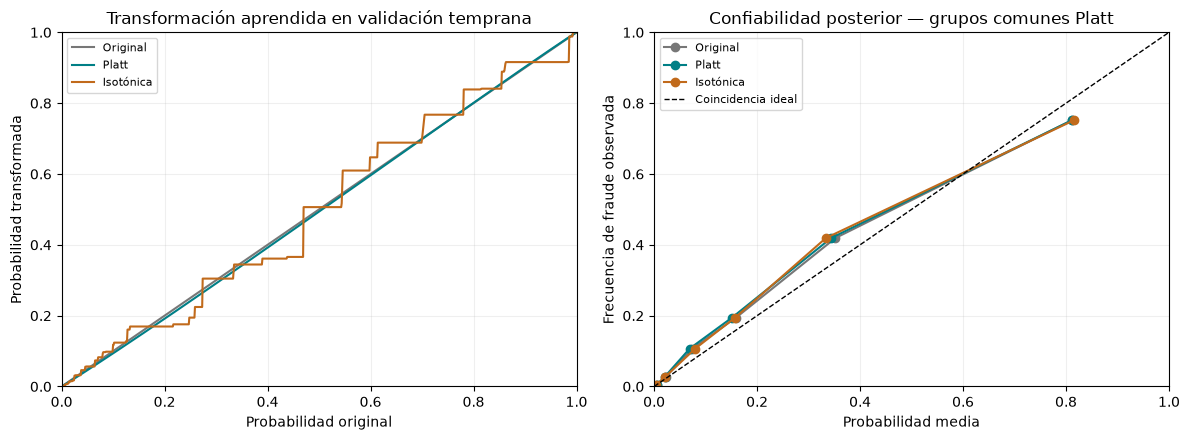

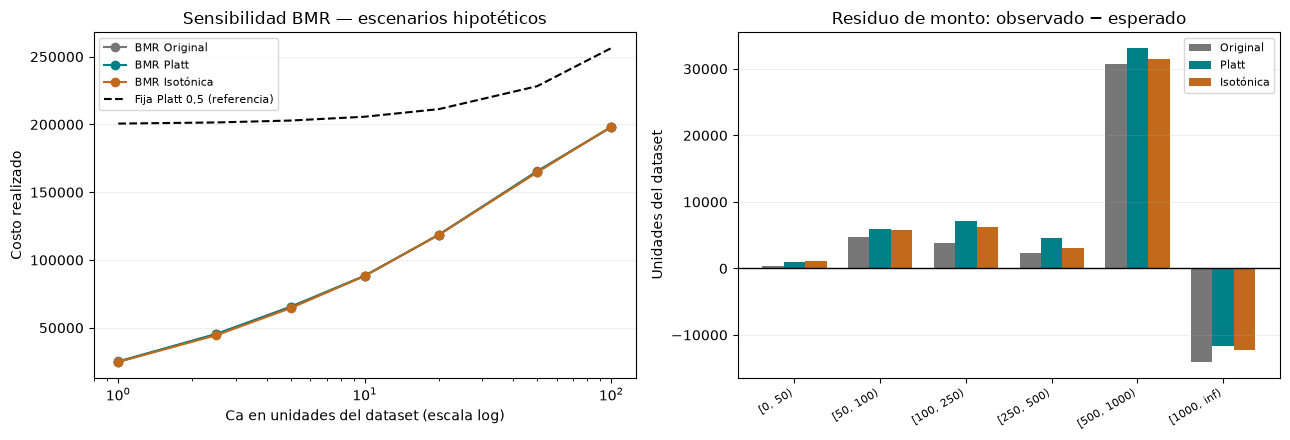

Comparación exportada. Isotónica sigue siendo candidata; escenarios finales pendientes.


In [5]:
figures = calibration_figures(predictor, isotonic, groups, comparison)
for figure in figures.values():
    display(figure)
record = save_calibration_experiment(PROJECT_ROOT, isotonic, metrics, groups, comparison,
                                     changes, diagnostics, figures, ca_grid=CA_GRID)
for figure in figures.values():
    plt.close(figure)
assert record['test_evaluated'] is False and record['selected_calibrator'] is None
print('Comparación exportada. Isotónica sigue siendo candidata; escenarios finales pendientes.')

## 6. Interpretación de esta corrida

Isotónica obtiene Brier=0,02491620 y log-loss=0,10088664: ambos mejoran ligeramente a Platt, pero raw conserva el menor log-loss (0,10079061). No encontramos una mejora uniforme por monto o periodo y todas las versiones subestiman la tasa agregada de fraude.

AP pasa de 0,46479424 a 0,44726786. Isotónica produce 82 probabilidades distintas y muchas mesetas: no invierte el orden de riesgo, pero los empates afectan esta métrica. También encontramos 819 probabilidades cero, una de ellas para un fraude posterior. Conservamos ese hallazgo sin suavizar las predicciones después de observar las etiquetas.

BMR isotónica cuesta menos que BMR Platt en seis de siete escenarios, pero empeora en Ca=100. En Ca=10 el costo disminuye solo 156,833 unidades (aproximadamente 0,177%); no confundimos este cambio pequeño con la ventaja de BMR frente a la política fija. Los escenarios comparten operaciones y no son réplicas independientes.

La literatura fundamenta escenarios de sensibilidad, no costos operativos reales de IEEE-CIS. Ca=1; 2,5; 5; 10 son valores numéricos inspirados en estudios previos; 20; 50; 100 amplían la sensibilidad. Todos permanecen hipotéticos y sin moneda verificada.

El predictor del 06 permanece intacto e isotónica se conserva como candidata. La validación posterior es desarrollo reutilizado, no confirmación independiente; no seleccionamos automáticamente un calibrador ni habilitamos test. El análisis completo y los controles se encuentran en [el informe de esta etapa](../docs/09_comparacion_calibradores_y_costos.md).